# BREAST CANCER CLASSIFICATION - EXPLORATORY DATA ANALYSIS

In this notebook we explore the **breast cancer dataset** to understand it's structure, distributions, relationships between features and patterns that may help classify tumors. 

# 1. Import Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 8)
plt.rcParams["figure.dpi"] = 100

%matplotlib inline

# 2. Load Dataset

In [77]:
df = pd.read_csv("dataset/breast-cancer.csv", index_col=False)

# remove the first column of data frame
del df[df.columns[0]]

print(f"rows: {df.shape[0]}, columns: {df.shape[1]}")
df.head()

rows: 569, columns: 31


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [78]:
len(df.columns)

31

## Column Description

| Column | id  | diagnosis | radius_mean | texture_mean | perimeter_mean | area_mean | smoothness_mean | compactness_mean | concavity_mean | concave points_mean | symmetry_mean | fractal_dimension_mean | radius_se | texture_se | perimeter_se | area_se | smoothness_se | compactness_se | concavity_se | concave points_se | symmetry_se | fractal_dimension_se | radius_worst | texture_worst | perimeter_worst | area_worst | smoothness_worst | compactness_worst | concavity_worst | concave points_worst | symmetry_worst | fractal_dimension_worst
|:-------- |:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|:--------:|
| Desc     | Unique ID of cell nucleus | Target: M - Malignant B - Benign | Radius of Lobes | Mean of Surface Texture | Outer Perimeter of Lobes | Mean Area of Lobes | Mean of Smoothness Levels | Mean of Compactness | Mean of Concavity | Mean of Cocave Points | Mean of Symmetry | Mean of Fractal Dimension | SE of Radius | SE of Texture | SE of Perimeter | SE of Area | SE of Smoothness | SE of compactness | SE of concavity | SE of concave points | SE of symmetry | SE of Fractal Dimension | Worst Radius | Worst Texture | Worst Permimeter | Worst Area | Worst Smoothness | Worse Compactness | Worst Concavity | Worst Concave Points | Worst Symmetry | Worst Fractal Dimension |

# 3. Dataset Overview

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [79]:
df.describe(include="O").T

/var/folders/zd/4sstc_8n4wbcrx7s414tx9400000gn/T/ipykernel_6250/778510885.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="O").T


,count,unique,top,freq
diagnosis,569,2,B,357


In [80]:
df.diagnosis.unique()

<StringArray>
['M', 'B']
Length: 2, dtype: str

# 4. Missing values Analysis

In [81]:
# Count and percentage of missing values
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print("Columns with missing values:")
missing

Columns with missing values:


,Missing Count,Missing %


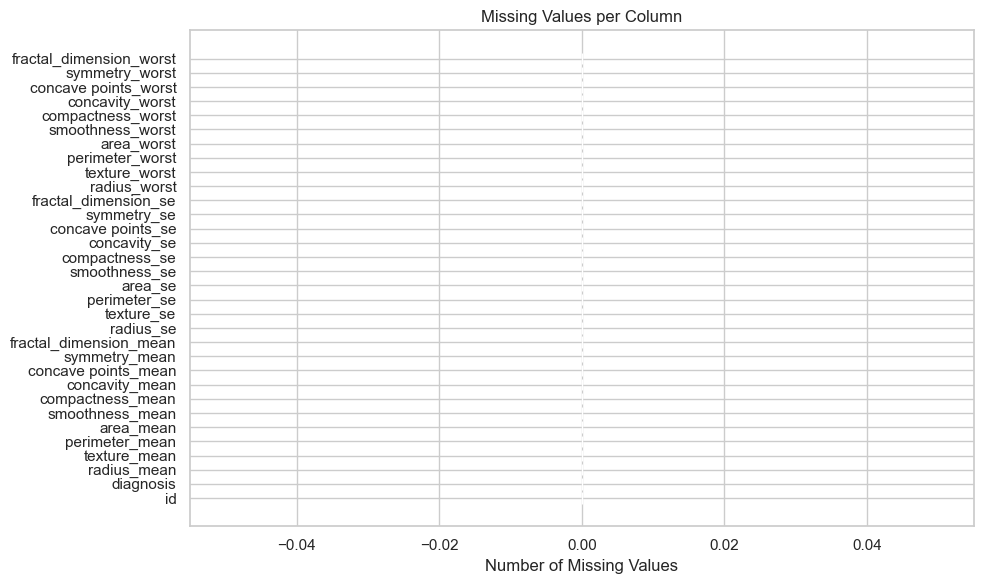

In [22]:

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c" if df[col].isnull().any() else "#2ecc71" for col in df.columns]
ax.barh(df.columns, df.isnull().sum(), color=colors)
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")
for i, v in enumerate(df.isnull().sum()):
    if v > 0:
        ax.text(v + 5, i, str(v), va="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Key observations :**  
* There is no missing values.

# 5. Target Variable Analysis

In [ ]:
# Diagnosis distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
diagnosis_counts = df["diagnosis"].value_counts()
axes[0].bar(["Benign (B)", "Malignant (M)"], diagnosis_counts.values,
            color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Diagnosis Count")
axes[0].set_ylabel("Count")
for i, v in enumerate(diagnosis_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(diagnosis_counts.values, labels=["Benign (B)", "Malignant (M)"],
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title("Diagnosis Percentage")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# print(f"\nBenign rate: {df['diagnosis'].mean():.2%}")
# print(f"Malignant rate: {1 - df['diagnosis'].mean():.2%}")

**Benign rate**: 62.7%  
**Malignant rate**: 37.3%  
The dataset is imbalanced — about 37% are mlaignant tumors and 63% are not.

# 6. Univariate Analysis — Numerical Features

In [83]:
len(numerical_cols)

30

In [ ]:
# Distribution of numerical features
numerical_cols = df.select_dtypes(exclude="object")

fig, axes = plt.subplots(10, 3, figsize=(20, 40))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, color="#3498db", edgecolor="white", alpha=0.8)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[i].axvline(df[col].median(), color="green", linestyle="--", label=f"Median: {df[col].median():.2f}")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend()

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

<Axes: ylabel='area_mean'>

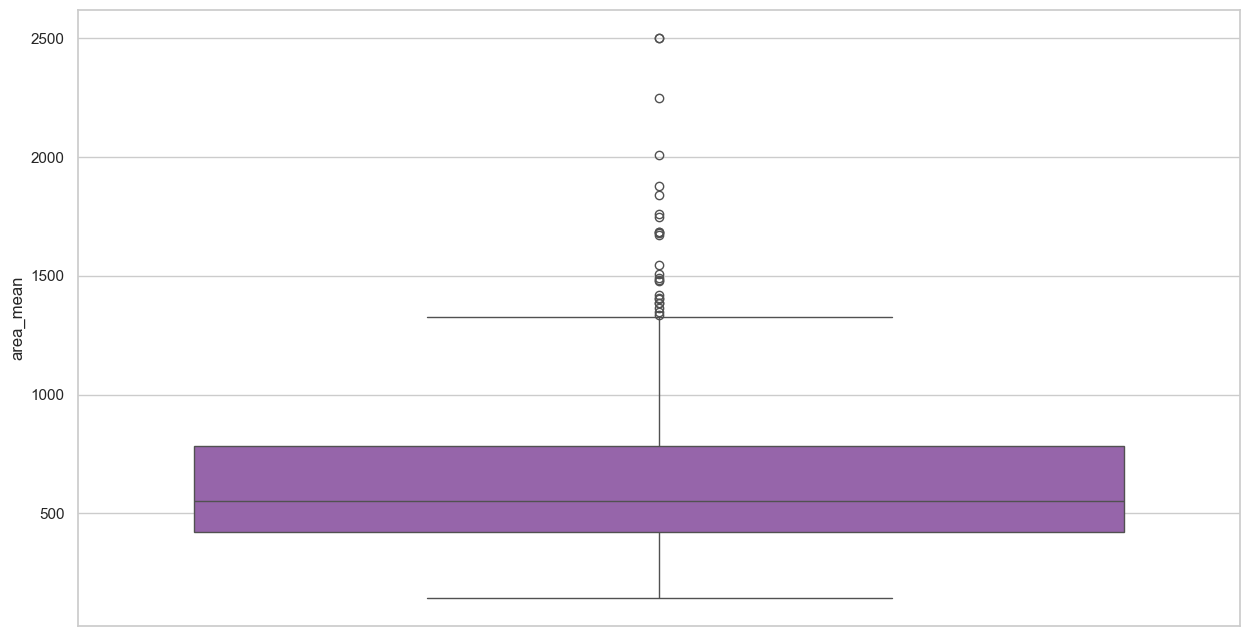

In [86]:
sns.boxplot(y=df['area_mean'], color="#9b59b6")

In [58]:
for i in range(0,30):
    print(f"{i//3}, {i%3}")

0, 0
0, 1
0, 2
1, 0
1, 1
1, 2
2, 0
2, 1
2, 2
3, 0
3, 1
3, 2
4, 0
4, 1
4, 2
5, 0
5, 1
5, 2
6, 0
6, 1
6, 2
7, 0
7, 1
7, 2
8, 0
8, 1
8, 2
9, 0
9, 1
9, 2


In [ ]:
# Box plots to check for outliers
fig, axes = plt.subplots(10, 3, figsize=(20, 40))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i // 3, i % 3], color="#9b59b6")
    axes[i // 3, i % 3].set_title(f"{col} — Box Plot")

plt.suptitle("Outlier Detection via Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations**:  
* **radius_mean; texture_mean; smoothness_mean; symmetry_mean; texture_se; fractal_dimension_mean; fractal_dimension_worst; concave_points_se; texture_worst; smoothness_worst; symmetry worst; concave points worst** :  
Roughly normaly distribued with some high outliers mostly significant for *radius_mean*, *symetry_mean*, *texture_se*, *fractal_dimension_mean*, *concave_points_se*, *fractal_dimension_worst* and *symetry_worst*.   

* The remaining variables are right-skewed, specialy heavy for *area_mean*, *concave_points_mean*, *concavity_mean*, *radius_se*, *area_se*, *perimeter_se*, *area_se*, *convacity_se* and *area_worst* with significant outliers.

# 7. Bivariate Analysis — Diagnosis vs Features

In [87]:
diagnosis_by = df.groupby(["diagnosis"]).mean()
diagnosis_by


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
M,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530


In [ ]:
# Diagnosis rate by features
fig, axes = plt.subplots(10, 3, figsize=(20, 40))

diagnosis_by = df.groupby(["diagnosis"]).mean()
for i, col in enumerate(numerical_cols):
    axes[i // 3, i % 3].bar(diagnosis_by.index, diagnosis_by[col], color=["#95d0ad", "#a45c54"])
    axes[i // 3, i % 3].set_title(f"Average {col} by Diagnosis")
    axes[i // 3, i % 3].set_ylabel(f"Average {col}")
    for j, v in enumerate(diagnosis_by[col]):
        axes[i // 3, i % 3].text(j, v + 0.02 * v, f"{v:.2f}", ha="center", fontweight="bold")

plt.suptitle("Average Feature Values by Diagnosis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()